Using device: cuda


100%|██████████| 182M/182M [00:02<00:00, 85.6MB/s] 


100%|██████████| 64.3M/64.3M [00:01<00:00, 37.5MB/s]


Epoch [1/100] - Loss: 1.4410, Accuracy: 52.08%
Epoch [2/100] - Loss: 1.0354, Accuracy: 67.27%
Epoch [3/100] - Loss: 0.9110, Accuracy: 71.32%
Epoch [4/100] - Loss: 0.8354, Accuracy: 73.93%
Epoch [5/100] - Loss: 0.7849, Accuracy: 75.68%
Epoch [6/100] - Loss: 0.7386, Accuracy: 77.30%
Epoch [7/100] - Loss: 0.7056, Accuracy: 77.99%
Epoch [8/100] - Loss: 0.6799, Accuracy: 78.76%
Epoch [9/100] - Loss: 0.6552, Accuracy: 79.67%
Epoch [10/100] - Loss: 0.6306, Accuracy: 80.41%
Epoch [11/100] - Loss: 0.6074, Accuracy: 81.05%
Epoch [12/100] - Loss: 0.5956, Accuracy: 81.41%
Epoch [13/100] - Loss: 0.5837, Accuracy: 81.91%
Epoch [14/100] - Loss: 0.5669, Accuracy: 82.27%
Epoch [15/100] - Loss: 0.5527, Accuracy: 82.75%
Epoch [16/100] - Loss: 0.5423, Accuracy: 82.90%
Epoch [17/100] - Loss: 0.5288, Accuracy: 83.42%
Epoch [18/100] - Loss: 0.5183, Accuracy: 83.69%
Epoch [19/100] - Loss: 0.5116, Accuracy: 83.82%
Epoch [20/100] - Loss: 0.5009, Accuracy: 84.17%
Epoch [21/100] - Loss: 0.4958, Accuracy: 84.32%
E

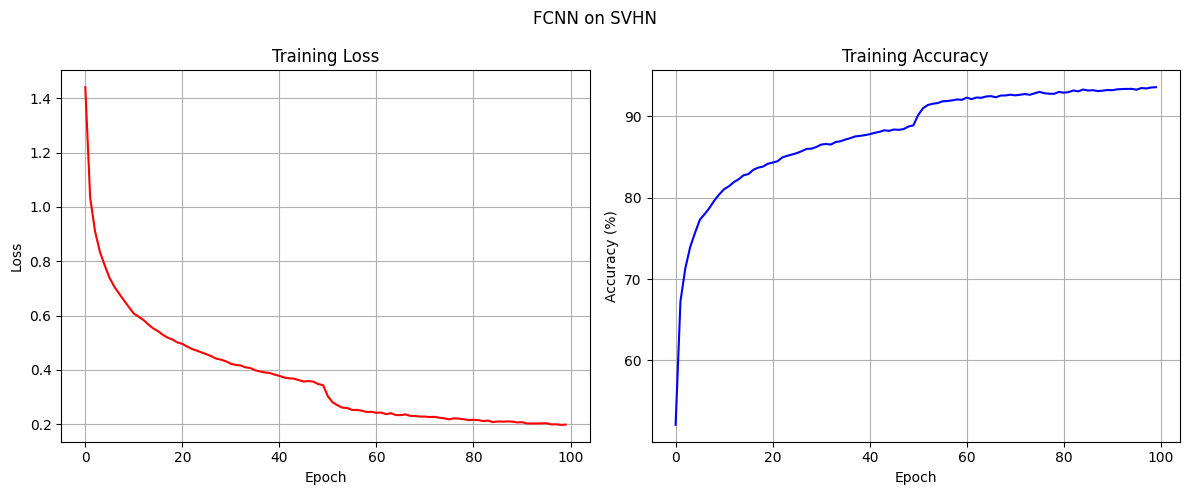


Test Accuracy: 86.74%


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.datasets import SVHN
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Device setup: use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Data preprocessing: Normalize based on SVHN dataset statistics
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4377, 0.4438, 0.4728], std=[0.1980, 0.2010, 0.1970])
])

# Download and load SVHN train and test sets
trainset = SVHN(root='./data', split='train', download=True, transform=transform)
testset = SVHN(root='./data', split='test', download=True, transform=transform)

trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
testloader = DataLoader(testset, batch_size=1000, shuffle=False)

# Fully Connected Neural Network model
class FCNNModel(nn.Module):
    def __init__(self):
        super(FCNNModel, self).__init__()
        self.classifier = nn.Sequential(
            nn.Linear(3 * 32 * 32, 2048),
            nn.BatchNorm1d(2048),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(2048, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(1024, 10)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten input
        return self.classifier(x)

# Training function
def run_training(model_class, num_epochs=100):
    model = model_class().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.1)

    train_losses = []
    train_accuracies = []

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        scheduler.step()

        epoch_loss = total_loss / len(trainloader)
        epoch_accuracy = 100 * correct / total

        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_accuracy)

        print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")

    return model, train_losses, train_accuracies

# Evaluation on test set
def evaluate_model(model):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f"\nTest Accuracy: {100 * correct / total:.2f}%")

# Plotting training loss and accuracy
def plot_metrics(train_losses, train_accuracies, title="Model Performance"):
    plt.figure(figsize=(12, 5))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="Loss", color='red')
    plt.title("Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label="Accuracy", color='blue')
    plt.title("Training Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.grid(True)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# Train FCNN on SVHN
fcnn_model, fcnn_losses, fcnn_accuracies = run_training(FCNNModel)

# Visualize training progress
plot_metrics(fcnn_losses, fcnn_accuracies, "FCNN on SVHN")

# Final evaluation on test data
evaluate_model(fcnn_model)
